# **Airline Passenger Satisfaction Classification**

## Introduction

The goal of this project is to predict whether an airline passenger is satisfied or not based on various features such as service quality, travel type, and customer demographics.

This is a supervised machine learning classification problem.

## Dataset Description: Airline Passenger Satisfaction


| Variable | Description |
|----------|-------------|
| `Gender` | Gender of the passengers (Female, Male) |
| `Customer_Type` | The customer type (Loyal customer, disloyal customer) |
| `Age` | The actual age of the passengers |
| `Type_of_Travel` | Purpose of the flight of the passengers (Personal Travel, Business Travel) |
| `Class` | Travel class in the plane of the passengers (Business, Eco, Eco Plus) |
| `Flight_Distance` | The flight distance of this journey |
| `Inflight_wifi_service` | Satisfaction level of the inflight wifi service (0:Not Applicable;1-5) |
| `Departure/Arrival_time_convenient` |  Satisfaction level of Departure/Arrival time convenient |
| `Ease_of_Online_booking` | Satisfaction level of online booking |
| `Gate_location` | Satisfaction level of Gate location |
| `Food_and_drink` | Satisfaction level of Food and drink |
| `Online_boarding` | Satisfaction level of online boarding |
| `Seat_comfort` | Satisfaction level of Seat comfort |
| `Inflight_entertainment` | Satisfaction level of inflight entertainment |
| `On-board_service` | Satisfaction level of On-board service |
| `Leg_room_service` | Satisfaction level of Leg room service |
| `Baggage_handling` | Satisfaction level of baggage handling |
| `Checkin_service` | Satisfaction level of Check-in service |
| `Inflight_service` | Satisfaction level of inflight service |
| `Cleanliness` | Satisfaction level of Cleanliness |
| `Departure_Delay_in_Minutes` | Minutes delayed when departure |
| `Arrival_Delay_in_Minutes` | Minutes delayed when Arrival |
| `satisfaction` | Airline satisfaction level(1: Satisfaction, 0: neutral or dissatisfaction) |


### IMPORTS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

### DATA LOADING AND PREPROCESSING

In [2]:
df = pd.read_csv("C:/Users/Ezgi/Downloads/train.csv")
target_col = 'satisfaction'
y = df[target_col]
x = df.drop(columns = [target_col])

### EXPLORATORY DATA ANALYSIS

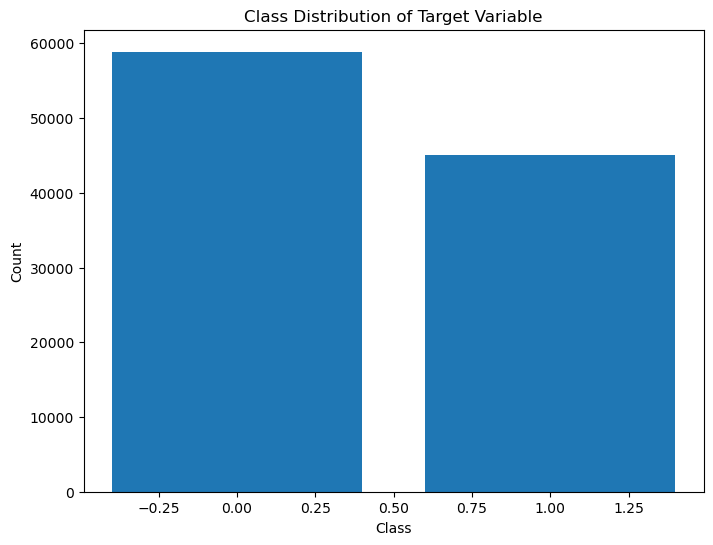

Categorical Columns: ['Gender', 'Customer_Type', 'Type_of_Travel', 'Class']
Numerical Columns: ['Age', 'Flight_Distance', 'Inflight_wifi_service', 'Departure/Arrival_time_convenient', 'Ease_of_Online_booking', 'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort', 'Inflight_entertainment', 'On-board_service', 'Leg_room_service', 'Baggage_handling', 'Checkin_service', 'Inflight_service', 'Cleanliness', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes', 'satisfaction']


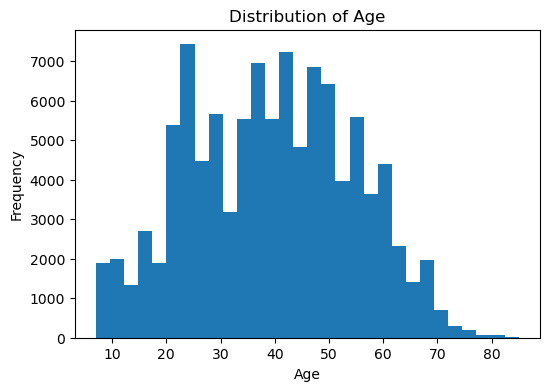

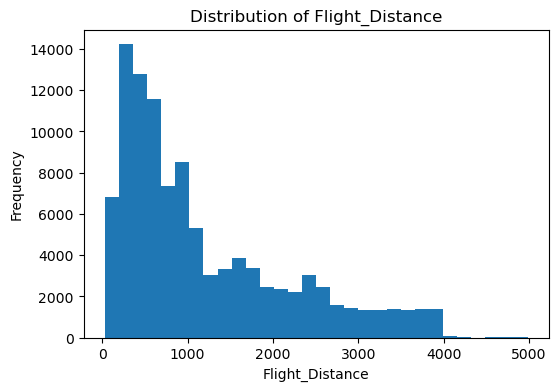

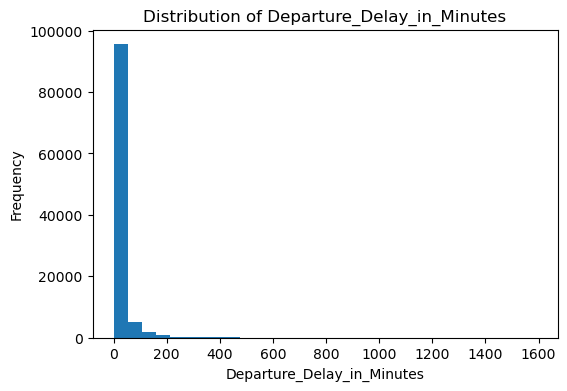

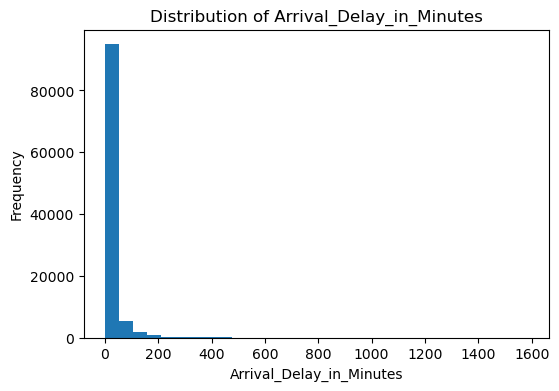

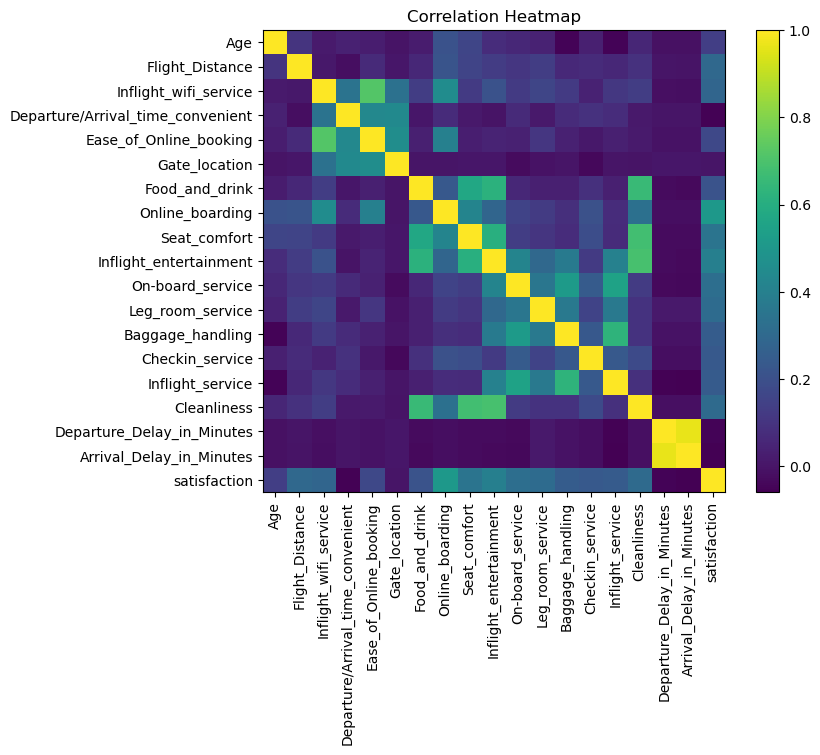

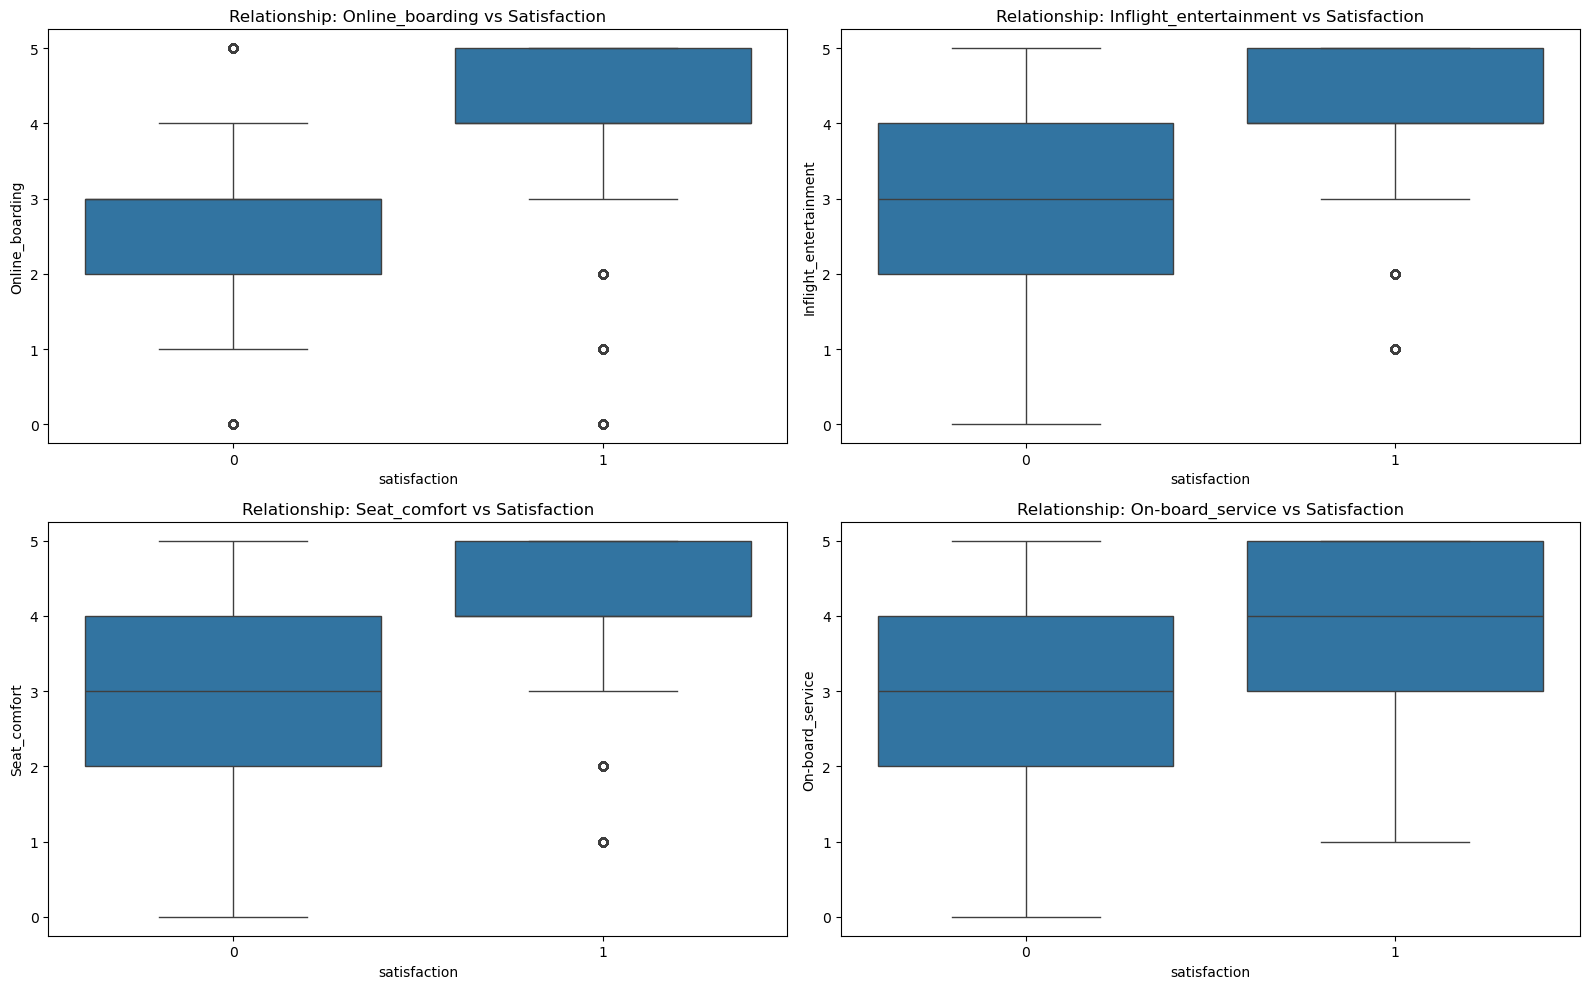

In [3]:
#target variable distribution
target_counts = df[target_col].value_counts()
plt.figure(figsize=(8,6))
plt.bar(target_counts.index, target_counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution of Target Variable")
plt.show()
target_counts

#analysis of missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

#identifying categorical and numerical features
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Categorical Columns:", list(categorical_cols))
print("Numerical Columns:", list(numerical_cols))

#distribution of features age, flight distance, departure delay, and arrival delay
cols_to_plot = ['Age', 'Flight_Distance', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes']
for col in cols_to_plot:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

#correlation heatmap
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap")
plt.show()

#box plots between target and the 4 columns with the most correlation with the target
target_corr = corr_matrix[target_col].abs()
top_4 = target_corr.sort_values(ascending = False).iloc[1:5].index

plt.figure(figsize=(16, 10))
for i, col in enumerate(top_4, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x= target_col, y=col, data=df)
    plt.title(f'Relationship: {col} vs Satisfaction')
plt.tight_layout()
plt.show()


### Analysis of High-Correlation Features
After identifying the features with the strongest relationship to customer satisfaction using the correlation heatmap, we use box plots to perform a better distribution analysis. This step makes it easier to understand how specific services influence a passenger satisfaction.
### Key Insights from Visualizations
* Features such as Online boarding and Inflight entertainment show a significant gap between the two classes. For satisfied passengers, the median score is consistently at the top levels (4 or 5), whereas dissatisfied passengers' scores are centered around 2 or 3. This indicates these features will be strong predictors for our classification model.
* In Seat comfort and On-board service, we observe that while dissatisfied passengers provide a wide range of scores, satisfied passengers almost never rate these below a 3. This suggests a "minimum acceptable quality" threshold for these services.
* The presence of low-score outliers in the 'Satisfied' group and high-score outliers in the 'Dissatisfied' group reminds us that satisfaction is multi-faceted; a passenger might be unhappy despite excellent boarding if another service (like flight delay) was poor.

In [4]:
#dropping unnecessary columns
df = pd.read_csv("C:/Users/Ezgi/Downloads/train.csv")
unnecessary_cols = ['id', 'Unnamed: 0']
cols_to_drop = [col for col in unnecessary_cols if col in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"Dropped columns: {cols_to_drop}")

#imputing missing values with median
delay_median = df['Arrival_Delay_in_Minutes'].median()
df['Arrival_Delay_in_Minutes'] = df['Arrival_Delay_in_Minutes'].fillna(delay_median)

#encoding
nominal_columns = ['Gender', 'Customer_Type', 'Type_of_Travel']
for col in nominal_columns:
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
    df = pd.concat([df, dummies], axis=1)
    df.drop(columns=[col], inplace=True)

#normalizing/standardizing
features_to_scale = df.select_dtypes(include=['number']).columns.tolist()
if 'satisfaction' in features_to_scale:
    features_to_scale.remove('satisfaction')
for col in features_to_scale:
    mean_val = df[col].mean()
    std_val = df[col].std()
    if std_val != 0:
        df[col] = (df[col] - mean_val) / std_val

### MODEL TRAINING

In [5]:
df_encoded = df.copy()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        unique_vals = df_encoded[col].unique()
        mapping = {val: idx for idx, val in enumerate(unique_vals)}
        df_encoded[col] = df_encoded[col].map(mapping)
df_shuffled = df_encoded.sample(frac=1, random_state=42).reset_index(drop=True)
train_size = int(len(df_shuffled)*0.8)
train_df = df_shuffled.iloc[:train_size]
val_df   = df_shuffled.iloc[train_size:]
X_train = train_df.drop('satisfaction', axis=1).values.astype(float)
y_train = train_df['satisfaction'].values
X_test  = val_df.drop('satisfaction', axis=1).values.astype(float)
y_test  = val_df['satisfaction'].values


In [6]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def logistic_regression(X, y, learning_rate = 0.01, epochs=1000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0
    for i in range(epochs):
        linear_model = np.dot(X, weights) + bias
        y_predicted = sigmoid(linear_model)
        dw = (1/n_samples)*np.dot(X.T, (y_predicted-y))
        db = (1/n_samples)*np.sum(y_predicted-y)
        weights = weights-(learning_rate*dw)
        bias = bias - (learning_rate*db)
    return weights, bias

def log_reg_predict(X, weights, bias):
    linear_model = np.dot(X, weights) + bias
    y_predicted = sigmoid(linear_model)
    y_cls = [1 if y >= 0.5 else 0 for y in y_predicted]
    return np.array(y_cls)

X_train = np.array(X_train)
X_test  = np.array(X_test)
y_train = np.array(y_train)
y_test  = np.array(y_test)

log_reg_weights, log_reg_bias = logistic_regression(X_train, y_train, learning_rate = 0.1, epochs = 300)
y_pred_lr = log_reg_predict(X_test, log_reg_weights, log_reg_bias)

def euclidean_distance(a,b):
    distance = np.sqrt(np.sum((a-b)**2))
    return distance

def knn_predict(X_train, y_train, X_test, k=5):
    predictions = []
    for x_test in X_test:
        distances = np.sqrt(np.sum((X_train - x_test)**2, axis=1))
        k_indices = np.argsort(distances)[:k]
        k_labels = y_train[k_indices]
        predictions.append(np.bincount(k_labels).argmax())
    return np.array(predictions)

y_knn_pred = knn_predict(X_train, y_train, X_test, k=5)

def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred)/len(y_true)
print("Logistic Regression Accuracy:", accuracy(y_test, y_pred_lr))
print("kNN Accuracy:", accuracy(y_test, y_knn_pred))


Logistic Regression Accuracy: 0.8592945479043357
kNN Accuracy: 0.9260863288580915


The very long execution time is caused by the kNN algorithm since it computes the distance between each test and training sample. It uses nested loops so the time complexity turns out to be quadratic. However, its accuracy is also high.

In [7]:
def confusion_matrix(y_true, y_pred):
    TP = TN = FN = FP = 0
    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 1:
            TP += 1
        elif y_true[i] == 0 and y_pred[i] == 0:
            TN += 1
        elif y_true[i] == 0 and y_pred[i] == 1:
            FP += 1
        elif y_true[i] == 1 and y_pred[i] == 0:
            FN += 1
    return TP, FP, FN, TN
def accuracy(TP, FP, FN, TN):
    return (TP + TN) / (TP + FP + FN + TN)
def precision(TP, FP):
    return TP / (TP + FP) if (TP + FP) != 0 else 0
def recall(TP, FN):
    return TP / (TP + FN) if (TP + FN) != 0 else 0
def f1_score(p, r):
    return (2 * p * r) / (p + r) if (p + r) != 0 else 0
TP, FP, FN, TN = confusion_matrix(y_test, y_pred_lr)

lr_acc = accuracy(TP, FP, FN, TN)
lr_prec = precision(TP, FP)
lr_rec = recall(TP, FN)
lr_f1 = f1_score(lr_prec, lr_rec)

print("Logistic Regression")
print("Confusion Matrix (TP, FP, FN, TN):", TP, FP, FN, TN)
print("Accuracy:", lr_acc)
print("Precision:", lr_prec)
print("Recall:", lr_rec)
print("F1-score:", lr_f1)

TP, FP, FN, TN = confusion_matrix(y_test, y_knn_pred)

knn_acc = accuracy(TP, FP, FN, TN)
knn_prec = precision(TP, FP)
knn_rec = recall(TP, FN)
knn_f1 = f1_score(knn_prec, knn_rec)

print("\nkNN")
print("Confusion Matrix (TP, FP, FN, TN):", TP, FP, FN, TN)
print("Accuracy:", knn_acc)
print("Precision:", knn_prec)
print("Recall:", knn_rec)
print("F1-score:", knn_f1)

Logistic Regression
Confusion Matrix (TP, FP, FN, TN): 7126 1160 1764 10731
Accuracy: 0.8592945479043357
Precision: 0.8600048274197442
Recall: 0.8015748031496063
F1-score: 0.8297624592454589

kNN
Confusion Matrix (TP, FP, FN, TN): 7909 555 981 11336
Accuracy: 0.9260863288580915
Precision: 0.9344281663516069
Recall: 0.8896512935883014
F1-score: 0.9114901463639508


We can clearly see that kNN performs better than logistic regression on this dataset. It has higher scores in both accuracy, precision, recall and f1-score. It' also apparent that false negatives are more frequent than false positives for both models, but especially for linear regression. This means that the model more often predicts a customer as not satisfied when they are actually satisfied.

In [8]:
feature_names = train_df.drop('satisfaction', axis = 1).columns
coefficients = log_reg_weights
feature_importance  =[]
for i in range(len(coefficients)):
    feature_importance.append((feature_names[i], abs(coefficients[i])))
feature_importance.sort(key = lambda x: x[1], reverse = True)
print("Top features influencing passenger satisfaction:")
for feature, importance in feature_importance[:5]:
    print(feature, ":", importance)

Top features influencing passenger satisfaction:
Type_of_Travel_Personal Travel : 1.0816543845131874
Online_boarding : 0.8613142635078923
Inflight_wifi_service : 0.4019906645289547
Customer_Type_disloyal Customer : 0.39228780244297157
Flight_Distance : 0.36921421149365674


With the use of this model, an airplane company can benefit from the knowledge of customer satisfaction and dissatisfaction statistics and what features play the biggest role in overall customer experience.